# Louvain Edge Severance

The GARG-AML pipeline pre-processes every transaction graph with Louvain community detection (resolution = 10, seed = 1997) and keeps only intra-community edges before computing the ego-graph block densities. A reviewer flagged that this step may obscure multi-mule rings that deliberately cross banks / rails. This notebook quantifies **what fraction of edges that pre-processing actually discards**, on every dataset the paper uses.

For each graph we report:

| column | meaning |
|---|---|
| `n_nodes` | number of nodes in the original graph |
| `n_edges_total` | edges before Louvain |
| `n_edges_intra` | edges retained after Louvain (intra-community only) |
| `n_edges_severed` | `n_edges_total - n_edges_intra` |
| `pct_severed` | `100 * n_edges_severed / n_edges_total` |
| `n_communities` | number of Louvain communities |

Both *directed* and *undirected* views of the graph are reported (the undirected one is the headline number, since Louvain operates on the symmetrised graph).

Outputs:

* `results/louvain_edge_severance.csv` &mdash; one row per (dataset, pipeline).
* `results/louvain_edge_severance.pdf` &mdash; boxplot of `pct_severed` by graph type and size.


In [1]:
# Run from the notebook directory; chdir to the repo root so the relative
# paths used elsewhere in the codebase work.
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
REPO_ROOT = os.getcwd()
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)
print("cwd:", REPO_ROOT)


cwd: /Users/brunodeprez/Library/CloudStorage/OneDrive-KULeuven/KUL-Docs/Research/Networks/11.FlowDetection/11.1 GARGAML/11.1.2 Code/GARG-AML


In [2]:
import time
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from src.data.graph_construction import construct_IBM_graph, construct_synthetic_graph
from src.utils.graph_processing import graph_community

OUT_CSV = Path("results/louvain_edge_severance.csv")
OUT_PDF = Path("results/louvain_edge_severance.pdf")
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)


## Helper

`edge_severance(G)` runs `graph_community(G)` (the exact function the pipeline uses) and returns the headline counts. Works for `Graph` and `DiGraph`.


In [3]:
def edge_severance(G):
    """Run Louvain on G via graph_community and report edge-level severance."""
    n_edges_total = G.number_of_edges()
    if n_edges_total == 0:
        return dict(
            n_nodes=G.number_of_nodes(),
            n_edges_total=0, n_edges_intra=0,
            n_edges_severed=0, pct_severed=float("nan"),
            n_communities=0,
        )
    H = graph_community(G)
    n_edges_intra = H.number_of_edges()

    # The number of communities equals the number of weakly-connected
    # components in the reduced graph plus any isolated nodes that ended
    # up alone. graph_community keeps all original nodes, so a cheap
    # estimate is the number of connected components of the undirected
    # view of H.
    H_und = H.to_undirected() if H.is_directed() else H
    n_communities = nx.number_connected_components(H_und)

    return dict(
        n_nodes=G.number_of_nodes(),
        n_edges_total=n_edges_total,
        n_edges_intra=n_edges_intra,
        n_edges_severed=n_edges_total - n_edges_intra,
        pct_severed=100.0 * (n_edges_total - n_edges_intra) / n_edges_total,
        n_communities=n_communities,
    )

def severance_both_views(loader, label):
    """Run severance on the undirected and directed views of the same graph."""
    rows = []
    for directed in [False, True]:
        t0 = time.perf_counter()
        G = loader(directed=directed)
        info = edge_severance(G)
        info.update(
            dataset=label,
            pipeline="directed" if directed else "undirected",
            louvain_seconds=time.perf_counter() - t0,
        )
        rows.append(info)
        del G
    return rows


## IBM datasets

`HI-Small` runs in a couple of minutes. `LI-Large` is ~16 GB on disk; it's gated behind `RUN_LI_LARGE` &mdash; flip the flag if you have time and memory to spare.


In [4]:
RUN_HI_SMALL = True
RUN_LI_LARGE = False   # ~16 GB CSV, hours of Louvain; opt in explicitly

ibm_rows = []

if RUN_HI_SMALL:
    path = "data/HI-Small_Trans.csv"
    print(f"Loading {path} ...")
    ibm_rows.extend(severance_both_views(
        lambda directed: construct_IBM_graph(path=path, directed=directed),
        label="HI-Small",
    ))

if RUN_LI_LARGE:
    path = "data/LI-Large_Trans.csv"
    print(f"Loading {path} (this will take a while) ...")
    ibm_rows.extend(severance_both_views(
        lambda directed: construct_IBM_graph(path=path, directed=directed),
        label="LI-Large",
    ))

ibm_df = pd.DataFrame(ibm_rows)
ibm_df


Loading data/HI-Small_Trans.csv ...


,n_nodes,n_edges_total,n_edges_intra,n_edges_severed,pct_severed,n_communities,dataset,pipeline,louvain_seconds
0,515080,644246,497614,146632,22.760250,116198,HI-Small,undirected,332.822333
1,515080,647939,501197,146742,22.647502,116213,HI-Small,directed,155.443144


## Synthetic datasets

66-point grid: `{Barabasi-Albert, Erdos-Renyi, Watts-Strogatz}` &times; sizes `{100, 10_000, 100_000}` &times; edge/rewiring params &times; `{3, 5}` injected patterns. The graph topology is the same regardless of injection type (`separate` / `new_mules` / `existing_mules`), so each of the 66 edge files is loaded once.

The 100k-node graphs take a few minutes each. `MAX_SYNTHETIC_SIZE` lets you cap the run.


In [5]:
def construct_dataset_names():
    """Mirror scripts/gargaml_directed_synth.py::construct_datasets() so the
    notebook stays in sync with the experimental grid."""
    names = []
    n_nodes_list = [100, 10000, 100000]
    m_edges_list = [1, 2, 5]
    p_edges_list = [0.001, 0.01]
    generators = ["Barabasi-Albert", "Erdos-Renyi", "Watts-Strogatz"]
    n_patterns_list = [3, 5]

    for n_nodes in n_nodes_list:
        for n_patterns in n_patterns_list:
            if n_patterns > 0.06 * n_nodes:
                continue
            for gen in generators:
                if gen == "Barabasi-Albert":
                    p_edges = 0
                    for m_edges in m_edges_list:
                        names.append(f"synthetic_{gen}_{n_nodes}_{m_edges}_{p_edges}_{n_patterns}")
                elif gen == "Erdos-Renyi":
                    m_edges = 0
                    for p_edges in p_edges_list:
                        names.append(f"synthetic_{gen}_{n_nodes}_{m_edges}_{p_edges}_{n_patterns}")
                else:  # Watts-Strogatz
                    for m_edges in m_edges_list:
                        for p_edges in p_edges_list:
                            names.append(f"synthetic_{gen}_{n_nodes}_{m_edges}_{p_edges}_{n_patterns}")
    return names

DATASET_NAMES = construct_dataset_names()
print(f"{len(DATASET_NAMES)} synthetic datasets in the grid")


66 synthetic datasets in the grid


In [6]:
MAX_SYNTHETIC_SIZE = 10_000  # set to 100_000 to include the largest graphs

def parse_size(name):
    return int(name.split("_")[2])

selected = [n for n in DATASET_NAMES if parse_size(n) <= MAX_SYNTHETIC_SIZE]
skipped = [n for n in DATASET_NAMES if parse_size(n) > MAX_SYNTHETIC_SIZE]
print(f"Selected: {len(selected)} | Skipped (size > {MAX_SYNTHETIC_SIZE}): {len(skipped)}")


Selected: 44 | Skipped (size > 10000): 22


In [7]:
synth_rows = []
for name in tqdm(selected):
    path = f"data/edge_data_{name}.csv"
    if not Path(path).is_file():
        print(f"  missing on disk, skipping: {path}")
        continue
    rows = severance_both_views(
        lambda directed, p=path: construct_synthetic_graph(path=p, directed=directed),
        label=name,
    )
    # Tag with grid coordinates for easy slicing in plots / tables.
    parts = name.split("_")
    for row in rows:
        row["generator"] = parts[1]
        row["n_nodes_grid"] = int(parts[2])
        row["m_edges"] = float(parts[3])
        row["p_edges"] = float(parts[4])
        row["n_patterns"] = int(parts[5])
    synth_rows.extend(rows)

synth_df = pd.DataFrame(synth_rows)
print(synth_df.shape)
synth_df.head()


100%|██████████| 44/44 [01:22<00:00,  1.88s/it] 

(88, 14)


,n_nodes,n_edges_total,n_edges_intra,n_edges_severed,pct_severed,n_communities,dataset,pipeline,louvain_seconds,generator,n_nodes_grid,m_edges,p_edges,n_patterns
0,145,199,127,72,36.180905,35,synthetic_Barabasi-Albert_100_1_0_3,undirected,0.005032,Barabasi-Albert,100,1.0,0.0,3
1,145,199,127,72,36.180905,35,synthetic_Barabasi-Albert_100_1_0_3,directed,0.004268,Barabasi-Albert,100,1.0,0.0,3
2,155,345,162,183,53.043478,40,synthetic_Barabasi-Albert_100_2_0_3,undirected,0.005851,Barabasi-Albert,100,2.0,0.0,3
3,155,345,162,183,53.043478,40,synthetic_Barabasi-Albert_100_2_0_3,directed,0.005735,Barabasi-Albert,100,2.0,0.0,3
4,141,582,123,459,78.865979,54,synthetic_Barabasi-Albert_100_5_0_3,undirected,0.007270,Barabasi-Albert,100,5.0,0.0,3


## Combine and persist


In [8]:
full_df = pd.concat([ibm_df, synth_df], ignore_index=True, sort=False)
full_df.to_csv(OUT_CSV, index=False)
print(f"wrote {OUT_CSV} ({len(full_df)} rows)")
full_df.head()


wrote results/louvain_edge_severance.csv (90 rows)


,n_nodes,n_edges_total,n_edges_intra,n_edges_severed,pct_severed,n_communities,dataset,pipeline,louvain_seconds,generator,n_nodes_grid,m_edges,p_edges,n_patterns
0,515080,644246,497614,146632,22.760250,116198,HI-Small,undirected,332.822333,NaN,NaN,NaN,NaN,NaN
1,515080,647939,501197,146742,22.647502,116213,HI-Small,directed,155.443144,NaN,NaN,NaN,NaN,NaN
2,145,199,127,72,36.180905,35,synthetic_Barabasi-Albert_100_1_0_3,undirected,0.005032,Barabasi-Albert,100.0,1.0,0.0,3.0
3,145,199,127,72,36.180905,35,synthetic_Barabasi-Albert_100_1_0_3,directed,0.004268,Barabasi-Albert,100.0,1.0,0.0,3.0
4,155,345,162,183,53.043478,40,synthetic_Barabasi-Albert_100_2_0_3,undirected,0.005851,Barabasi-Albert,100.0,2.0,0.0,3.0


## Headline numbers for the paper

Two summaries:

1. **IBM** &mdash; report exactly the numbers from `ibm_df` in the appendix.
2. **Synthetic** &mdash; mean &plusmn; std of `pct_severed` per (generator, n_nodes), undirected view.


In [9]:
print("=== IBM ===")
print(ibm_df[["dataset", "pipeline", "n_nodes", "n_edges_total",
              "n_edges_intra", "pct_severed", "n_communities"]].to_string(index=False))


=== IBM ===
 dataset   pipeline  n_nodes  n_edges_total  n_edges_intra  pct_severed  n_communities
HI-Small undirected   515080         644246         497614    22.760250         116198
HI-Small   directed   515080         647939         501197    22.647502         116213


In [10]:
print("=== Synthetic (undirected view) ===")
agg = (synth_df[synth_df["pipeline"] == "undirected"]
       .groupby(["generator", "n_nodes_grid"])["pct_severed"]
       .agg(["mean", "std", "min", "max", "count"])
       .round(2))
print(agg.to_string())


=== Synthetic (undirected view) ===
                               mean    std    min    max  count
generator       n_nodes_grid                                   
Barabasi-Albert 100           53.19  20.32  27.49  78.87      6
                10000         43.78  33.52   3.55  77.95      6
Erdos-Renyi     100           29.09  18.83  10.20  49.03      4
                10000         39.55  44.31   1.05  77.99      4
Watts-Strogatz  100           43.95  12.06  25.09  61.22     12
                10000          5.03   1.40   3.49   7.36     12


## Plot


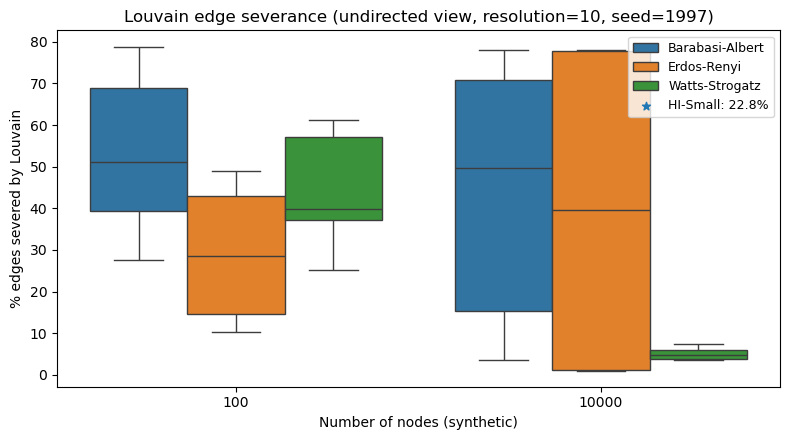

wrote results/louvain_edge_severance.pdf


In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
undir = synth_df[synth_df["pipeline"] == "undirected"].copy()
undir["size_label"] = undir["n_nodes_grid"].astype(str)
sns.boxplot(
    data=undir, x="size_label", y="pct_severed", hue="generator",
    order=sorted(undir["size_label"].unique(), key=int),
    ax=ax,
)
# Overlay IBM points so the appendix figure shows both regimes.
for _, row in ibm_df[ibm_df["pipeline"] == "undirected"].iterrows():
    ax.scatter([], [], label=f"{row['dataset']}: {row['pct_severed']:.1f}%", marker="*")
ax.set_xlabel("Number of nodes (synthetic)")
ax.set_ylabel("% edges severed by Louvain")
ax.set_title("Louvain edge severance (undirected view, resolution=10, seed=1997)")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_PDF)
plt.show()
print(f"wrote {OUT_PDF}")
